<a href="https://colab.research.google.com/github/Deepaksoni-dot/Deepaksoni-dot/blob/MachineLearning/LDA_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.datasets import load_digits

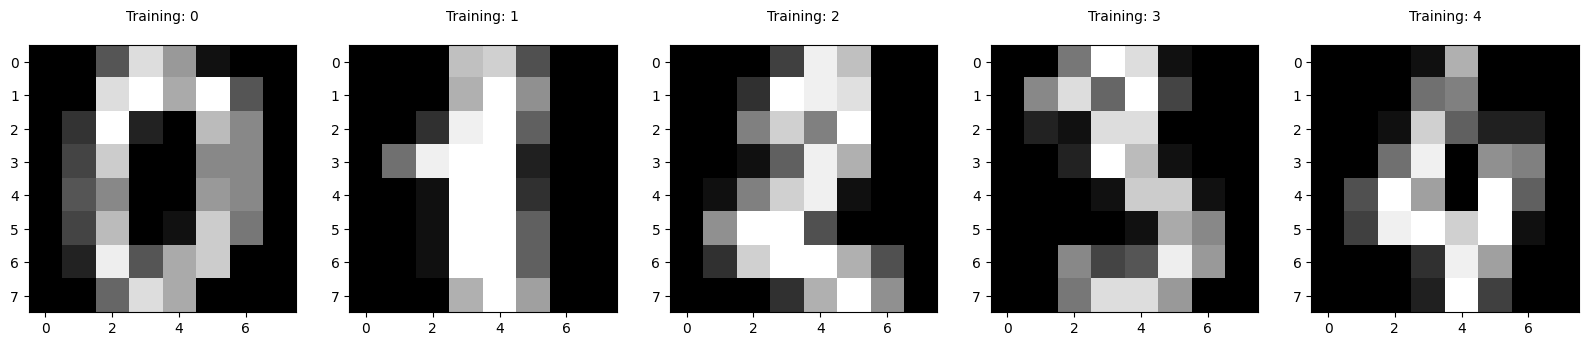

In [ ]:
digits = load_digits()
plt.figure(figsize=(20,4)) #size of canvas
for index, (image, label) in enumerate(zip(digits.data[0:5], digits.target[0:5])): # first 5 records
    plt.subplot(1, 5, index + 1)
    plt.imshow(np.reshape(image, (8,8)), cmap=plt.cm.gray)
    plt.title('Training: %i\n' % label, fontsize = 10)

In [ ]:
digits.data.shape

(1797, 64)

In [ ]:
df = pd.DataFrame(digits.data)
df['target'] = digits.target
df.head()

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [ ]:
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

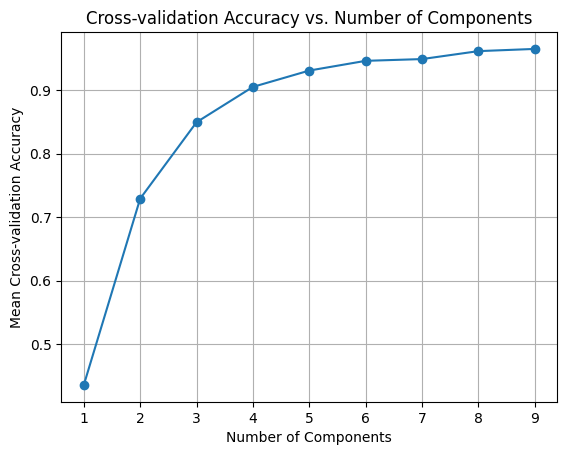

In [ ]:
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y,stratify=y, test_size=0.2, random_state=42)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
max_components=min(len(np.unique(y_train))-1,X_train.shape[1])
mean_scores=[]
for i in range(1,max_components+1):
  X_train_lda=lda.transform(X_train)[:,:i]
  scores=cross_val_score(lda,X_train_lda,y_train,cv=5)
  mean_scores.append(np.mean(scores))
plt.plot(range(1, max_components + 1), mean_scores, marker='o')
plt.title('Cross-validation Accuracy vs. Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Mean Cross-validation Accuracy')
plt.grid(True)
plt.show()

In [ ]:
#from graph we see we can choose 4 components for good cross_val_score
# we can transform data X_test using new_data=lda.transform(X_test)[:,:4]


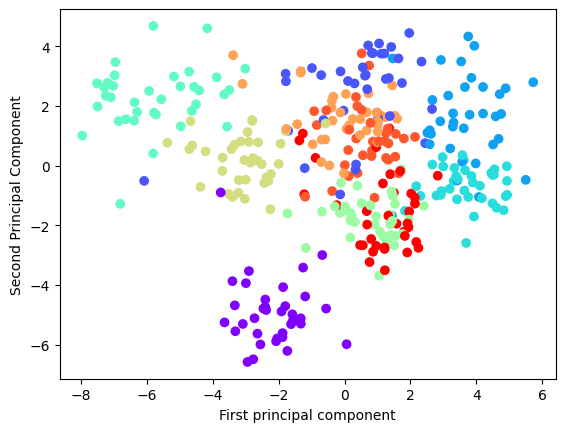

In [ ]:
#plot the data
new_data=lda.transform(X_test)[:,:2]
plt.scatter(new_data[:,0],new_data[:,1],c=y_test,cmap='rainbow')
plt.xlabel('First principal component')
plt.ylabel('Second Principal Component')
plt.show()

In [ ]:
#Obviously we are finding the components with minimum inner class variance and maximum inter class variance
# That why we can see cluster in this plot
# heart of classification

In [ ]:
X_train=lda.transform(X_train)
X_test=lda.transform(X_test)

In [ ]:
# prompt: apply random forest with n estimator = 100

from sklearn.ensemble import RandomForestClassifier

# Initialize and train the RandomForestClassifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model (example: accuracy)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of Random Forest: {accuracy}")


Accuracy of Random Forest: 0.9611111111111111


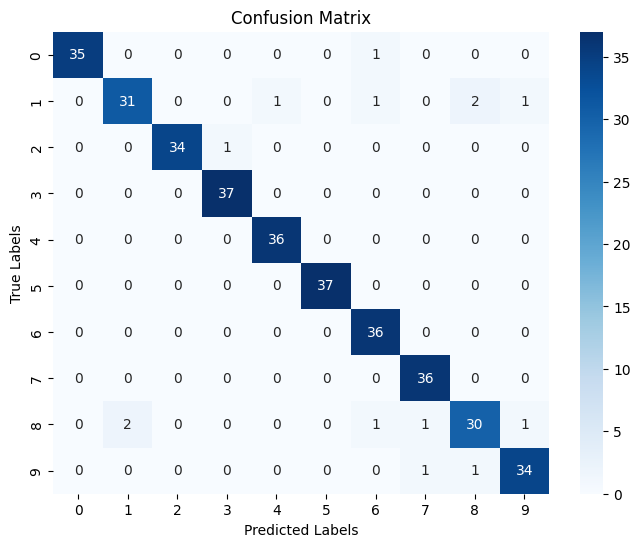

In [ ]:
# prompt: create confusion matrix for particular value of y_test

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming y_test and y_pred are already defined from the previous code

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()
